<a href="https://colab.research.google.com/github/Katyapuchkova1/Diploma/blob/main/%D0%9F%D1%80%D0%BE%D0%B3%D1%80%D0%B0%D0%BC%D0%BC%D0%B0_%D0%B4%D0%BB%D1%8F_%D0%92%D0%9A%D0%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install razdel
!pip install pymorphy2
!pip install pypandoc
!pip install shutil
!pip install PyPDF2
!pip install python-pptx
!pip3 install urllib2
!pip install matplotlib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 64.5 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13704 sha256=e980e4237544844dde981a47f3af0a6d7d49fb51e1932e283c33bda887341ef9
  Stored in directory: /root/.cache/pip/wheels/fc/ab/d4/5da2067ac95b36618c629a5f93f809425700506f72c9732fac
Successfully built docopt
ERROR: Could not find a version that satisfies the requirement shutil (from versions: none)
ERROR: No matching distribution found for shutil
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.9/159.9 kB 12.0 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement urllib2 (from versions: none)
ERROR: No matching distribution found for 

In [ ]:
!unzip /content/1class_pptx/1-20240324T011321Z-001.zip -d /content/1class_pptx
!unzip /content/2class_pptx/2-20240324T011340Z-001.zip -d /content/2class_pptx
!unzip /content/3class_pptx/3-20240323T231937Z-001.zip -d /content/3class_pptx

In [ ]:
!mv /content/1class_pptx/1/* /content/1class_pptx
!mv /content/2class_pptx/2/* /content/2class_pptx
!mv /content/3class_pptx/3/* /content/3class_pptx

In [ ]:
from os import listdir
from os.path import isfile, join
mypath = '/content/docx_files'
onlyfiles = ['/content/docx_files/' + f for f in listdir(mypath) if isfile(join(mypath, f))]

In [ ]:
import pypandoc
import shutil

def converter_from_docx_to_txt(onlyfiles, difficulty):
  for docxFilename in onlyfiles:
    print(docxFilename)
    output = pypandoc.convert_file(docxFilename, 'plain', outputfile=docxFilename[:-4]+".txt")
    shutil.copy(docxFilename[:-4]+".txt", '/content/' + str(difficulty))

In [ ]:
mypath = '/content/docx_files'
onlyfiles = ['/content/docx_files/' + f for f in listdir(mypath) if isfile(join(mypath, f))]
converter_from_docx_to_txt(onlyfiles, 4)

In [ ]:
from pptx import Presentation

def get_txt_from_pptx_memory(level_of_difficulty):
    '''Перевод из pptx в txt и сохранение в память'''

  mypath = '/content/' + str(level_of_difficulty) + 'class_pptx/'
  onlyfiles_pptx = [f for f in listdir(mypath) if isfile(join(mypath, f))]

  for path_to_presentation in onlyfiles_pptx:
    prs = Presentation(mypath + path_to_presentation)
    text_runs = ''

    for slide in prs.slides:
        for shape in slide.shapes:
            if not shape.has_text_frame:
                continue
            for paragraph in shape.text_frame.paragraphs:
                for run in paragraph.runs:
                    text_runs += run.text
    with open('/content/' + str(level_of_difficulty) + '/' + path_to_presentation[:-4] + 'txt', 'w') as f:
      f.write(text_runs)
  return None

In [ ]:
from PyPDF2 import PdfReader

def get_txt_from_pdf_memory(level_of_difficulty):
  '''Перевод из pdf в txt и сохранение в память'''

  mypath = '/content/' + str(level_of_difficulty) + '_new_class_pdf/'
  onlyfiles_pdf = [f for f in listdir(mypath) if isfile(join(mypath, f))]

  for filename_pdf in onlyfiles_pdf:
    reader = PdfReader(mypath + filename_pdf)
    number_of_pages = len(reader.pages)
    text = ''
    for page_num in range(number_of_pages):
      text += reader.pages[page_num].extract_text()
    with open('/content/' + str(level_of_difficulty) + '/' + filename_pdf[:-3] + 'txt', 'w') as f:
      f.write(text)
  return None

In [ ]:
from google.colab import files

def download_files(level_of_difficulty):
  mypath = '/content/' + str(level_of_difficulty) + '/'
  onlyfiles = [mypath + f for f in listdir(mypath) if isfile(join(mypath, f))]

  for filename in onlyfiles:
    files.download(filename)

  return None



In [ ]:
download_files(1)
download_files(2)
download_files(3)
download_files(4)

In [ ]:
import requests
import re
from bs4 import BeautifulSoup
from os import listdir
from os.path import isfile, join

def get_frec_dict(url):
  htmldata = requests.get('http://dict.ruslang.ru/freq.php?act=show&dic=freq_v&title=%D7%E0%F1%F2%EE%F2%ED%FB%E9%20%F1%EF%E8%F1%EE%EA%20%E3%EB%E0%E3%EE%EB%EE%E2').text
  soup = BeautifulSoup(htmldata, 'html.parser')
  data = ''
  dict_not_parsed = soup.find_all("p")[0].get_text()
  dict_parsed = re.findall(r'[а-яё]+[0-9]+.[0-9]+', dict_not_parsed)
  dict_new = []
  for elem in dict_parsed:
      m = re.search('[а-яё]+', elem)
      dict_new += [m[0]]
  return dict_new

url_noun = 'https://dict.ruslang.ru/freq.php?act=show&dic=freq_s&title=%D7%E0%F1%F2%'
url_verbs = 'http://dict.ruslang.ru/freq.php?act=show&dic=freq_v&title=%D7%E0%F1%F2%EE%F2%ED%FB%E9%20%F1%EF%E8%F1%EE%EA%20%E3%EB%E0%E3%EE%EB%EE%E2'
url_adjectives = 'http://dict.ruslang.ru/freq.php?act=show&dic=freq_adj&title=%D7%E0%F1%F2%EE%F2%ED%FB%E9%20%F1%EF%E8%F1%EE%EA%20%E8%EC%E5%ED%20%EF%F0%E8%EB%E0%E3%E0%F2%E5%EB%FC%ED%FB%F5'
url_adverbs = 'http://dict.ruslang.ru/freq.php?act=show&dic=freq_adv&title=%D7%E0%F1%F2%EE%F2%ED%FB%E9%20%F1%EF%E8%F1%EE%EA%20%ED%E0%F0%E5%F7%E8%E9%20%E8%20%EF%F0%E5%E4%E8%EA%E0%F2%E8%E2%EE%E2'
url_pronouns = 'http://dict.ruslang.ru/freq.php?act=show&dic=freq_pro&title=%D7%E0%F1%F2%EE%F2%ED%FB%E9%20%F1%EF%E8%F1%EE%EA%20%EC%E5%F1%F2%EE%E8%EC%E5%ED%E8%E9%20(%EC%E5%F1%F2%EE%E8%EC%E5%ED%E8%FF-%F1%F3%F9%E5%F1%F2%E2%E8%F2%E5%EB%FC%ED%FB%E5,%20%EF%F0%E8%EB%E0%E3%E0%F2%E5%EB%FC%ED%FB%E5,%20%ED%E0%F0%E5%F7%E8%FF,%20%EF%F0%E5%E4%E8%EA%E0%F2%E8%E2%FB)'
url_numerals = 'http://dict.ruslang.ru/freq.php?act=show&dic=freq_num&title=%D7%E0%F1%F2%EE%F2%ED%FB%E9%20%F1%EF%E8%F1%EE%EA%20%F7%E8%F1%EB%E8%F2%E5%EB%FC%ED%FB%F5'
url_lemmas_official_part_of_speech = 'http://dict.ruslang.ru/freq.php?act=show&dic=freq_other&title=%D7%E0%F1%F2%EE%F2%ED%FB%E9%20%F1%EF%E8%F1%EE%EA%20%EB%E5%EC%EC%20%F1%EB%F3%E6%E5%E1%ED%FB%F5%20%F7%E0%F1%F2%E5%E9%20%F0%E5%F7%E8'
dict_nouns_1000 = get_frec_dict(url_noun)
dict_verbs_1000 = get_frec_dict(url_verbs)
dict_adjectives_1000 = get_frec_dict(url_adjectives)
dict_adverbs_1000 = get_frec_dict(url_adverbs)
dict_pronouns_1000 = get_frec_dict(url_pronouns)
dict_numerals_1000 = get_frec_dict(url_numerals)
dict_lemmas_official_part_of_speech_1000 = get_frec_dict(url_lemmas_official_part_of_speech)

list_dicts = [dict_nouns_1000, dict_verbs_1000, dict_adjectives_1000, dict_adverbs_1000, dict_pronouns_1000, dict_numerals_1000, dict_lemmas_official_part_of_speech_1000]
not_standart_grammems = ['latn', 'pnct', 'numb', 'intg', 'real', 'romn', 'unkn']

list_names = ['qnt_freq_nouns', 'qnt_freq_verbs', 'qnt_freq_adjectives', 'qnt_freq_adverbs', 'qnt_freq_pronouns', 'qnt_freq_numerals', 'qnt_freq_lemmas_official_part_of_speech']

In [ ]:
import requests
from bs4 import BeautifulSoup
def get_frec_dict(url):
  '''Скачивание тэга <p> со страницы'''

  htmldata = requests.get(url).text
  with open('\content\this.txt', 'w') as f:
    f.write(htmldata)
  soup = BeautifulSoup(htmldata, 'html.parser')
  data = ''
  dict_not_parsed = soup.get_text()
  return dict_not_parsed

print(get_frec_dict('https://psylist.net/pedagogika/dicsre002.html'))

<!DOCTYPE html><html lang="en-US"><head><title>Just a moment...</title><meta http-equiv="Content-Type" content="text/html; charset=UTF-8"><meta http-equiv="X-UA-Compatible" content="IE=Edge"><meta name="robots" content="noindex,nofollow"><meta name="viewport" content="width=device-width,initial-scale=1"><style>*{box-sizing:border-box;margin:0;padding:0}html{line-height:1.15;-webkit-text-size-adjust:100%;color:#313131}button,html{font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,Roboto,Helvetica Neue,Arial,Noto Sans,sans-serif,Apple Color Emoji,Segoe UI Emoji,Segoe UI Symbol,Noto Color Emoji}@media (prefers-color-scheme:dark){body{background-color:#222;color:#d9d9d9}body a{color:#fff}body a:hover{color:#ee730a;text-decoration:underline}body .lds-ring div{border-color:#999 transparent transparent}body .font-red{color:#b20f03}body .big-button,body .pow-button{background-color:#4693ff;color:#1d1d1d}body #challenge-success-text{background-image:url()}body #challenge-error-text

In [ ]:
import itertools, requests
from bs4 import BeautifulSoup

url = 'https://opencorpora.org/dict.php?act=gram&order=id'
htmldata = requests.get(url).text
soup = BeautifulSoup(htmldata, 'html.parser')
data = ''
tr_list = soup.find_all('tr')
tr_list = tr_list[1:]
list_td_s = []
for elem in tr_list:
  list_td_s += [elem.find_all('td')]

def from_tuple_to_str(tuple_of_strs):
  res = ''
  for elem in tuple_of_strs:
    res += elem
  return res

punctuation = '''!@#$%^&*(){}[]|._-`/?:;"'–\,~«»'''
grammems = []
for elem in list_td_s:
  grammems += [elem[1].text.lower()]
print(list((1, 2, 3)))
list_grammems = list(map(lambda x: x[0] + ' ' + x[1], itertools.product(grammems, repeat=2)))
rus_alphabet = 'абвгдеёжзийклммнопрстуфхцчшщъыьэюя'
not_standart_grammems = ['latn', 'pnct', 'numb', 'intg', 'real', 'romn', 'unkn']
combs_3_kon = list(map(from_tuple_to_str, itertools.product(rus_alphabet, repeat=3)))
combs_2_kon = list(map(from_tuple_to_str, itertools.product(rus_alphabet, repeat=2)))
combs_1_kon = list(map(from_tuple_to_str, itertools.product(rus_alphabet, repeat=1)))
vector_of_params = grammems + combs_3_kon + combs_2_kon + combs_1_kon +  not_standart_grammems + list_names
print(vector_of_params)
print(len(vector_of_params))
print(len(set(vector_of_params)))



In [ ]:
import nltk
from razdel import tokenize, sentenize
import pymorphy2

def get_text_vec(filename, vector_of_params):
  print(len(vector_of_params))
  dict_statistics = {}
  for elem in vector_of_params:
    dict_statistics[elem] = 0
  f = open(filename)
  text = f.read().lower()
  punctuation = '''!@#$%^&*(){}[]|._-`/?»:«;"'\,~'''

  list_sentences = list(sentenize(text))
  num_sentences = len(list_sentences)
  tokens_str = []

  for sentence in list_sentences:
    tokens = list(tokenize(sentence.text))
    tokens_str += [_.text for _ in tokens]

  def dict_modify(frec_dict, name_param, my_dict, token):
    if token in frec_dict:
      my_dict[name_param] += 1
    return my_dict

  morph = pymorphy2.MorphAnalyzer()
  for token in tokens_str:

    parsed = morph.parse(token)[0]
    tag_str = str(parsed.tag).lower().split(',')
    for grammem in tag_str:
      if grammem.find(' ') == -1:
        dict_statistics[grammem] += 1
    if len(token) >= 3:
      in_dict_3 = token[-3:]
      if in_dict_3 in vector_of_params: dict_statistics[in_dict_3] += 1
    if len(token) >= 2:
      in_dict_2 = token[-2:]
      if in_dict_2 in vector_of_params: dict_statistics[in_dict_2] += 1
    in_dict_1 = token[-1]
    if in_dict_1 in vector_of_params: dict_statistics[in_dict_1] += 1
    for i in range(len(list_names)):
      dict_statistics = dict_modify(list_dicts[i], list_names[i], dict_statistics, token)
  return dict_statistics






In [ ]:
#Формирование признакового описания
def find_X_y(level_of_difficulty):
  X, y = [], []
  mypath = '/content/sample_data/' + str(level_of_difficulty) + '/' + ''
  onlyfiles = [mypath + f for f in listdir(mypath) if isfile(join(mypath, f))]
  counter = 1
  for filename in onlyfiles:
    counter += 1
    print(counter)
    X.append(get_text_vec(filename, vector_of_params).values())
  return X

X, y = [], []
counter = 1
levels_of_difficulty = [i for i in range(1, 5)]
for i in levels_of_difficulty:
  X.append([find_X_y(i)])
  y.append(i)

print(X)
print(y)




In [ ]:
def make_y():
  y = []
  class_1 = 1
  class_5 = 5
  for i in range(class_1, class_5):
    mypath = '/content/sample_data/' + str(i) + '/'
    len_dir_level = len([mypath + f for f in listdir(mypath) if isfile(join(mypath, f))])
    for k in range(len_dir_level):
      y.append([i])
  return y

#пишем набор данных в файл
import numpy as np
dataset_x = []
res = []
for elem in X:
  dataset_x += elem[0]

dataset_x = list(map(lambda x: list(x), dataset_x))

def load_to_file(filename, dataset):
  with open(filename, 'w') as f:
    for elem in dataset:
      if len(elem) == 1:
        f.write(str(elem[0]))
      else:
        f.write(' '.join(list(map(lambda x: str(x), elem))))
      f.write('\n')
  return None
file_to_download_X = '/content/sample_data/dataset_X.txt'
file_to_download_y = '/content/sample_data/dataset_y.txt'
load_to_file(file_to_download_X, dataset_x)
load_to_file(file_to_download_y, make_y())

In [ ]:
files.download('/content/sample_data/dataset_y.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Обучаем линейную регрессию

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.33, random_state=42)
reg = LinearRegression().fit(X_train, y_train)

print(reg.score(X_test, y_test))

In [ ]:
letters = ['й, ц, у, к, е, н, г, ш, щ, з, х, ъ, ф, ы, в, а, п, р, о, л, д, ж, э, я, ч, с, м, и, т, ь, б, ю']
vowels = ['а', 'е', 'ы', 'у', 'э', 'о', 'я', 'и', 'ю']
punctuation = [',', ';', '.', ':', '?', ')', '(', '!']

In [ ]:
#Получение словаря сложных слов
from nltk.tokenize import RegexpTokenizer
import requests
from bs4 import BeautifulSoup
tokenizer=RegexpTokenizer(r'\n\w{4,}\n')
url_diff = 'https://mydocx.ru/9-118219.html'
vocab = requests.get(url_diff)
soup = BeautifulSoup(vocab.content, 'html.parser')
text_vocab = soup.get_text()
vocab_del = tokenizer.tokenize(text_vocab.lower())
vocab = map(lambda x: x.strip('\n'), vocab_del)
vocab_dif = list(vocab)[1:]

In [ ]:
constant_scaling = 4
#Метрики удобочитаемости

def calc_Flesh_Kincaid_rus(n_syllabes, n_words, n_sent):
    """Метрика Flesh Kincaid для русского языка"""
    constant_scaling = 4
    n = 220.755 - 1.315 * (float(n_words) / n_sent) - 50.1 * (float(n_syllabes) / n_words)
    return n/constant_scaling

def calc_Flesh_Kincaid_Grade_rus(n_syllabes, n_words, n_sent):
    """Метрика Flesh Kincaid Grade для русского языка"""
    constant_scaling = 4
#    n = 0.59 * (float(n_words) / n_sent) + 6.2 * (float(n_syllabes) / n_words) - 16.59
    n = 0.49 * (float(n_words) / n_sent) + 7.3 * (float(n_syllabes) / n_words) - 16.59
    return n/constant_scaling

FLG_X_GRADE = 0.318
FLG_Y_GRADE = 14.2
FLG_Z_GRADE = 30.5

def calc_Flesh_Kincaid_Grade_rus_flex(n_syllabes, n_words, n_sent):
    """Метрика Flesh Kincaid Grade для русского языка с константными параметрами"""
    constant_scaling = 4
    if n_words == 0 or n_sent == 0: return 0
    n = FLG_X_GRADE * (float(n_words) / n_sent) + FLG_Y_GRADE * (float(n_syllabes) / n_words) - FLG_Z_GRADE
    return n/constant_scaling

CLI_X_GRADE = 0.055
CLI_Y_GRADE = 0.35
CLI_Z_GRADE = 20.33


def calc_Coleman_Liau_index(n_letters, n_words, n_sent):
    """ Метрика Coleman Liau для русского языка с константными параметрами """
    constant_scaling = 4
    if n_words == 0: return 0
    n = CLI_X_GRADE * (n_letters * (100.0 / n_words)) - CLI_Y_GRADE * (n_sent * (100.0 / n_words)) - CLI_Z_GRADE
    return n/constant_scaling

SMOG_X_GRADE = 1.
SMOG_Y_GRADE = 64.6
SMOG_Z_GRADE = 0.05

def calc_SMOG_index(n_psyl, n_sent):
    """Метрика SMOG для русского языка с константными параментрами"""
    constant_scaling = 4
    n = SMOG_X_GRADE * sqrt((float(SMOG_Y_GRADE) / n_sent) * n_psyl) + SMOG_Z_GRADE
    return n/constant_scaling

DC_X_GRADE = 0.552
DC_Y_GRADE = 0.273

def calc_Dale_Chale_index(n_psyl, n_words, n_sent):
    """Метрика Dale Chale для русского языка с константным параметрами"""
    constant_scaling = 4
    n = DC_X_GRADE * (100.0 * n_psyl / n_words) + DC_Y_GRADE * (float(n_words) / n_sent)
    return n/constant_scaling

ARI_X_GRADE = 6.26
ARI_Y_GRADE = 0.2805
ARI_Z_GRADE = 31.04


def calc_ARI_index(n_letters, n_words, n_sent):
    """ Метрика Automated Readability Index (ARI) для русского языка с константными параметрами """
    constant_scaling = 4
    if n_words == 0 or n_sent == 0: return 0
    n = ARI_X_GRADE * (float(n_letters) / n_words) + ARI_Y_GRADE * (float(n_words) / n_sent) - ARI_Z_GRADE
    return n/constant_scaling

def get_y_flesh_kincaid_rus(data_x):
    y = []
    for elem in data_x:
      y_new = calc_Flesh_Kincaid_rus(elem[3], elem[1], elem[0])
      y.append(y_new)
    return y

def get_y_flesh_kinkaid_grade_rus(data_x):
    y = []
    for elem in data_x:
      y_new = calc_Flesh_Kincaid_Grade_rus(elem[3], elem[1], elem[0])
      y.append(y_new)
    return y

def get_y_flesh_kinkaid_grade_rus(data_x):
    y = []
    for elem in data_x:
      y_new = calc_Flesh_Kincaid_Grade_rus(elem[3], elem[1], elem[0])
      y.append(y_new)
    return y


In [ ]:
from string import punctuation
import nltk
from nltk import sent_tokenize, word_tokenize
nltk.download('punkt')

def count_metrics(text):
  """Подсчет основных характеристик текста"""
  sents = sent_tokenize(text)
  num_sent = len(sents)
  num_words = 0
  num_letters = 0
  num_syl = 0
  num_hardwords = 0
  for sent in sents:
    words = word_tokenize(sent)
    words_cleaned =  list(filter(lambda x: x not in punctuation, words))
    num_words += len(words_cleaned)
    for word in words_cleaned:
      if word in vocab_dif: num_hardwords += 1
      num_letters += len(word)
      for letter in word:
        if letter in vowels: num_syl += 1
  return (num_sent, num_words, num_letters, num_syl, num_hardwords)

text = 'Я был сегодня во дворе. Моих друзей там не было.'
count_metrics = count_metrics


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
level_of_difficulties = [i for i in range(1, 5)]
from os import listdir
from os.path import isfile, join

def find_X_metrics_begtin():
  X = []
  for level in level_of_difficulties:
    mypath = '/content/sample_data/' + str(level) + '/'
    onlyfiles = [mypath + f for f in listdir(mypath) if isfile(join(mypath, f))]
    for filename in onlyfiles:
      with open(filename, 'r') as f:
        text = f.read()
        X.append(list(count_metrics(text)))
  return X

data_metrics_x = find_X_metrics_begtin()


NameError: name 'count_metrics' is not defined

In [ ]:
def load_to_file(filename, dataset):
  with open(filename, 'w') as f:
    for elem in dataset:
      if len(elem) == 1:
        f.write(str(elem[0]))
      else:
        f.write(' '.join(list(map(lambda x: str(x), elem))))
      f.write('\n')
  return None

load_to_file('/content/sample_data/metrics_x.txt', data_metrics_x)

NameError: name 'data_metrics_x' is not defined

In [ ]:
#X по Бегтину

data_metrics_x = get_set('/content/sample_data/metrics_x.txt')
data_x = get_set('/content/sample_data/dataset_x.txt')
data_y = get_set('/content/sample_data/dataset_y.txt')


#X - 40000 признаков
data_x = data_x
data_y = data_y

In [ ]:
from sklearn.metrics import coverage_error
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.33, random_state=42)
X_train_metrics, X_test_metrics, y_train_metrics, y_test_metrics = train_test_split(data_metrics_x, data_y, test_size=0.33, random_state=42)
y_pred_metrics = np.asarray(get_y_flesh_kincaid_rus(X_test_metrics))
y_pred_metrics_new = y_pred_metrics[y_pred_metrics >= 0]
y_test_metrics_new = y_test_metrics[y_pred_metrics >= 0]

def changing_to_classification(y):
  new = []
  for elem in y:
    if elem >= 1 and elem <= 4:
      new += [1]
    elif elem >= 5 and elem <= 9:
      new += [2]
    elif elem >= 10 and elem <= 11:
      new += [3]
    else:
      new += [4]
  new = np.asarray(new)
  return new

def changing_y(y, x_test_metrics, func):
  y = np.asarray(func(x_test_metrics))
  y_new = y[y >= 0]
  y_changed = changing_to_classification(y_changed)
  return y_changed

changing_y(y, x_test_metrics)



[4 4 4 4 4 4 4 4 4 4 4 4 4 3 4 4 4 4 4 4 4 4 4 4 4 3 4 4 4 2 4 4 4 4 4 4 4
 4 4 3 4 4 4 4 4 4 4 4 4 4 4 3 4]
[3 3 2 1 3 1 3 2 4 3 1 1 1 2 1 1 3 1 3 1 1 1 3 2 3 2 1 4 1 4 3 2 4 1 3 3 2
 3 1 1 4 2 3 3 1 3 1 3 3 3 1 2 3]


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
data_x = fit_transform(data_x)
X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.33, random_state=42)
reg = LinearRegression().fit(X_train, y_train)

y_pred = reg.predict(X_test)
mask = (y_pred>=1)&(y_pred<=4)
#y_pred_new, y_test_new - Линейная регрессия
y_pred_new = np.round(y_pred).astype(int)[mask]
y_test_new = y_test[mask]

print(y_pred_new)
print(y_test_new)
print(y_pred)
from sklearn.metrics import accuracy_score

linear_regression_score = accuracy_score(y_test_new, y_pred_new)
begtin_flesh_kinkaid_rus_score = accuracy_score(y_test_metrics_new, y_pred_in_classification)
print(linear_regression_score)
print(begtin_flesh_kinkaid_rus_score)

In [ ]:
#Тестирование Lasso регрессии

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.33, random_state=42)
reg = Lasso(alpha=2).fit(X_train, y_train)

y_pred = reg.predict(X_test)
mask = (y_pred>=1)&(y_pred<=4)
#y_pred_new, y_test_new - Линейная регрессия
y_pred_new = np.round(y_pred).astype(int)[mask]
y_test_new = y_test[mask]

linear_regression_score = accuracy_score(y_test_new, y_pred_new)

In [ ]:
#Здесь происходит разбиение датасета. Из одного текста полусаются тексты по 200 слов в каждом.
import nltk
nltk.download('punkt')
from nltk import sent_tokenize, word_tokenize
from os import listdir
from os.path import join, isfile


name_file = 'texts_for_dataset'

for i in range(1, 5):
  mypath = '/content/sample_data/' + str(i) + '/'
  onlyfiles = [mypath + f for f in listdir(mypath) if isfile(join(mypath, f))]
  directory_to_write = '/content/sample_data/'
  counter_files = 0
  for filename in onlyfiles:
    with open(filename, 'r') as f:
      text = f.read()
      splitted_text = word_tokenize(text)
      if len(splitted_text) > 200:
        for j in range(0, len(splitted_text), 200):
          file_to_write =  directory_to_write + str(i) + 'texts_new_new_to_dataset/' + str(counter_files) + '.txt'
          counter_files += 1
          with open(file_to_write, 'w') as f:
            if j + 200 <= len(splitted_text):
              f.write(' '.join(splitted_text[j:j + 200]))
            else:
              f.write(''.join(splitted_text[j:len(splitted_text)]))










[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
def load_to_file(filename, dataset):
  with open(filename, 'w') as f:
    for elem in dataset:
      if len(elem) == 1:
        f.write(str(elem[0]))
      else:
        f.write(' '.join(list(map(lambda x: str(x), elem))))
      f.write('\n')
  return None

In [ ]:
#Формирование признакового описания
def find_X_y(level_of_difficulty):
  X, y = [], []
  mypath = '/content/sample_data/' + str(level_of_difficulty) + 'texts_new_new_to_dataset/' + ''
  onlyfiles = [mypath + f for f in listdir(mypath) if isfile(join(mypath, f))]
  counter = 1
  for filename in onlyfiles:
    counter += 1
    print(counter)
    t = list(get_text_vec(level_of_difficulty, filename, vector_of_params).values())

  return X

X, y = [], []
counter = 1
levels_of_difficulty = [i for i in range(1, 5)]
for i in levels_of_difficulty:
  X.append([find_X_y(i)])
  y += [[i]]

print(len(X[0]))



In [ ]:
#Формирование признакового описания

all_texts = 0

for i in range(1, 5):
  mypath = '/content/sample_data/' + str(i) + 'texts_new_new_to_dataset/'
  onlyfiles = [mypath + f for f in listdir(mypath) if isfile(join(mypath, f))]
  all_texts += len(onlyfiles)

print(all_texts)

def find_X_y():
  X, y = [], []
  counter = 0
  for i in range(1, 5):
    mypath = '/content/sample_data/' + str(i) + 'texts_new_new_to_dataset/'
    onlyfiles = [mypath + f for f in listdir(mypath) if isfile(join(mypath, f))]
    for filename in onlyfiles:
      t = [list(get_text_vec(i, filename, vector_of_params).values())]
      X += t
      y += [[i]]
      counter += 1
      print(counter)
      if counter > 10000:
        break
  return X, y

tuple_dataset = find_X_y()

In [ ]:
dataset_x = tuple_dataset[0]
dataset_y = tuple_dataset[1]
print(len(dataset_x))
print(len(elem))
def load_to_file(filename, dataset):
  with open(filename, 'w') as f:
    for elem in dataset:
      if len(elem) == 1:
        f.write(str(elem[0]))
      else:
        f.write(' '.join(list(map(lambda x: str(x), elem))))
      f.write('\n')
  return None
file_to_download_X = '/content/sample_data/dataset_x_new.txt'
file_to_download_y = '/content/sample_data/dataset_y_new.txt'
load_to_file(file_to_download_X, dataset_x)
load_to_file(file_to_download_y, dataset_y)

In [ ]:
import numpy as np
def get_set(filename_dataset):
  dataset_nums = []
  data = []
  with open(filename_dataset, 'r') as f:
    strs = f.readlines()
    for line in strs:
      if len(line) > 2:
        new = line.split()
        new = list(map(lambda x: int(x), new))
        data += [new]
      else:
        new = int(line)
        data += [new]
  return data

In [ ]:
f_dataset_x = '/content/sample_data/dataset_x_new.txt'
f_dataset_y = '/content/sample_data/dataset_y_new.txt'
data_x = get_set(f_dataset_x)
data_y = get_set(f_dataset_y)

In [ ]:
vector_of_features = get_text_vec('/content/sample_data/1_texts_new_new_to_dataset/1grade.txt', vector_of_params).keys()
file_for_features = '/content/sample_data/features.txt'
string_to_write = ' '.join(vector_of_features)
with open(file_for_features, 'w') as f:
  f.write(string_to_write)

NameError: name 'get_text_vec' is not defined

In [ ]:
from sklearn.utils import shuffle

data_y = data_y[:9332]
data_x, data_y = shuffle(data_x, data_y)
data_x = data_x[:1000]
data_y = data_y[:1000]

filename_x = '/content/sample_data/data_x_1000.txt'
filename_y = '/content/sample_data/data_y_1000.txt'
load_to_file(filename_x, data_x)
load_to_file(filename_y, data_y)


NameError: name 'data_y' is not defined

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
#Эксперимент с отбором признаков. Нормализация StandartScaler

accuracy_score_ = []

def get_accuracy_ovr(X, y):

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

  ovr_model = LogisticRegression(multi_class = 'ovr')
  ovr_model = ovr_model.fit(X_train, y_train)
  y_pred = ovr_model.predict(X_test)

  return accuracy_score(y_pred, y_test)

for i in range(1, 1000):
  X = df[vector_of_features[:i]]
  y = df['target']
  scaler = StandardScaler()
  data_x = scaler.fit_transform(X)
  data_y = y
  accuracy_score_.append(get_accuracy_ovr(data_x, data_y))

x = list(i for i in range(1, 1000))



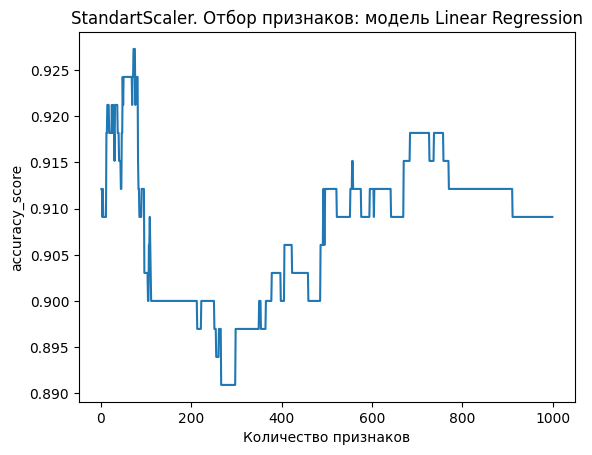

In [ ]:
plt.plot(x, accuracy_score_,)
plt.xlabel("Количество признаков")
plt.ylabel("accuracy_score")
plt.title("StandartScaler. Отбор признаков: модель Linear Regression")
plt.savefig("standart_lin_reg_coefs.png")

In [ ]:
find_maximal = np.argmax(accuracy_score_)
print("Максимальное значение accuracy получается на", find_maximal, "признаках, accuracy равно", accuracy_score_[find_maximal])

Максимальное значение accuracy получается на 71 признаках, accuracy равно 0.9272727272727272


In [ ]:
from sklearn.preprocessing import MinMaxScaler
#Эксперимент с отбором признаков. Нормализация MinMaxScaler

accuracy_score_ = []

def get_accuracy_ovr(X, y):

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

  ovr_model = LogisticRegression(multi_class = 'ovr')
  ovr_model = ovr_model.fit(X_train, y_train)
  y_pred = ovr_model.predict(X_test)

  return accuracy_score(y_pred, y_test)

for i in range(1, 1000):
  X = df[vector_of_features[:i]]
  y = df['target']
  scaler = MinMaxScaler()
  data_x = scaler.fit_transform(X)
  data_y = y
  accuracy_score_.append(get_accuracy_ovr(data_x, data_y))



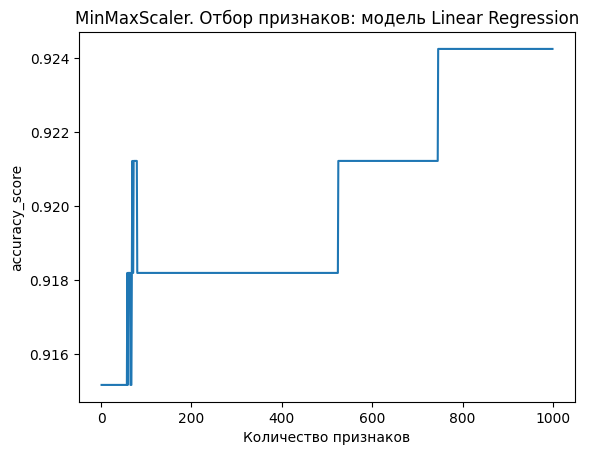

In [ ]:
plt.plot(x, accuracy_score_,)
plt.xlabel("Количество признаков")
plt.ylabel("accuracy_score")
plt.title('MinMaxScaler. Отбор признаков: модель Linear Regression')
plt.savefig("minmax_lin_reg_coefs.png")

In [ ]:
find_maximal = np.argmax(accuracy_score_)
print("Максимальное значение accuracy получается на", find_maximal, "признаках, accuracy равно", accuracy_score_[find_maximal])

Максимальное значение accuracy получается на 745 признаках, accuracy равно 0.9242424242424242


In [ ]:
with open('/content/sample_data/features_correlation.txt') as f:
  features = f.read()
  vector_of_features_corr = features.split()


In [ ]:
#Признаки, полученные исходя из корреляции
from sklearn.preprocessing import MinMaxScaler
#Эксперимент с отбором признаков. Нормализация MinMaxScaler

accuracy_score_ = []

def get_accuracy_ovr(X, y):

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

  ovr_model = LogisticRegression(multi_class = 'ovr')
  ovr_model = ovr_model.fit(X_train, y_train)
  y_pred = ovr_model.predict(X_test)

  return accuracy_score(y_pred, y_test)

for i in range(1, 1000):
  X = df[vector_of_features_corr[:i]]
  y = df['target']
  scaler = MinMaxScaler()
  data_x = scaler.fit_transform(X)
  data_y = y
  accuracy_score_.append(get_accuracy_ovr(data_x, data_y))

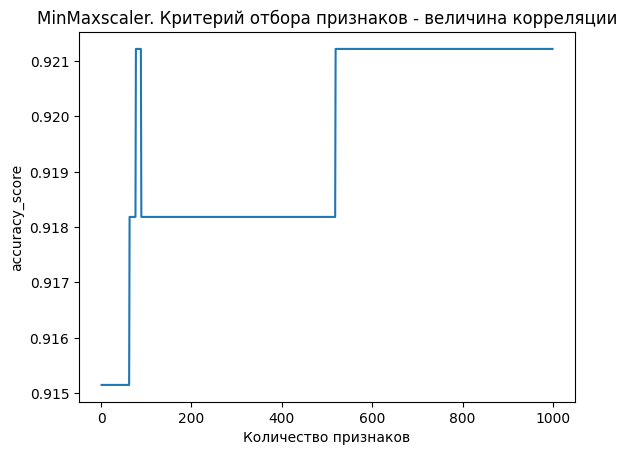

In [ ]:
plt.plot(x, accuracy_score_,)
plt.xlabel("Количество признаков")
plt.ylabel("accuracy_score")
plt.title("MinMaxscaler. Критерий отбора признаков - величина корреляции")
plt.savefig("minmax_lin_corr.png")

In [ ]:
find_maximal = np.argmax(accuracy_score_)
print("Максимальное значение accuracy получается на", find_maximal, "признаках, accuracy равно ", accuracy_score_[find_maximal])

Максимальное значение accuracy получается на 76 признаках, accuracy равно  0.9212121212121213


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
#Эксперимент с отбором признаков. Нормализация StandartScaler

accuracy_score_ = []

def get_accuracy_ovr(X, y):

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

  ovr_model = LogisticRegression(multi_class = 'ovr')
  ovr_model = ovr_model.fit(X_train, y_train)
  y_pred = ovr_model.predict(X_test)

  return accuracy_score(y_pred, y_test)

for i in range(1, 1000):
  X = df[vector_of_features_corr[:i]]
  y = df['target']
  scaler = StandardScaler()
  data_x = scaler.fit_transform(X)
  data_y = y
  accuracy_score_.append(get_accuracy_ovr(data_x, data_y))

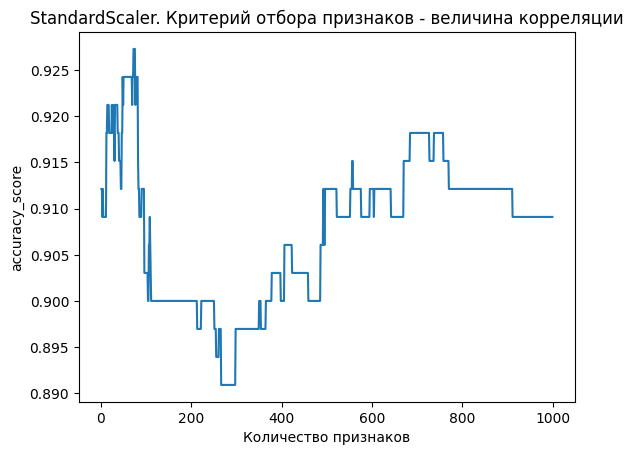

In [ ]:
plt.plot(x, accuracy_score_,)
plt.xlabel("Количество признаков")
plt.ylabel("accuracy_score")
plt.title("StandardScaler. Критерий отбора признаков - величина корреляции")
plt.savefig("standart_scaler_corr.png")

In [ ]:
find_maximal = np.argmax(accuracy_score_)
print("Максимальное значение accuracy получается на", find_maximal, "признаках, accuracy равно ", accuracy_score_[find_maximal])

Максимальное значение accuracy получается на 72 признаках, accuracy равно  0.9272727272727272


In [ ]:
from sklearn.feature_selection import VarianceThreshold

In [ ]:
file_for_features = '/content/sample_data/features.txt'
string_to_write = ' '.join(vector_of_features)
with open(file_for_features, 'w') as f:
  f.write(string_to_write)

NameError: name 'vector_of_features' is not defined

In [ ]:
#Признаки полученные исходя из корреляции
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
#Эксперимент с отбором признаков. Нормализация MinMaxScaler

accuracy_score_ = []

def get_accuracy_ovr(X, y):

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

  ovr_model = LogisticRegression(multi_class = 'ovr')
  ovr_model = ovr_model.fit(X_train, y_train)
  y_pred = ovr_model.predict(X_test)

  return accuracy_score(y_pred, y_test)

X = df.drop('target', axis=1)
y = df['target']
data_y = y
sel = VarianceThreshold(threshold=(.8 * (1 - .8)))
data_x = sel.fit_transform(X)
for i in range(1, 1000):
  try:
    data_x = data_x.iloc[:, :i]
  except:
    accuracy_score_.append(None)
    continue
  scaler = MinMaxScaler()
  data_x = scaler.fit_transform(data_x)
  accuracy_score_.append(get_accuracy_ovr(data_x, data_y))

ValueError: Found input variables with inconsistent numbers of samples: [1, 1000]

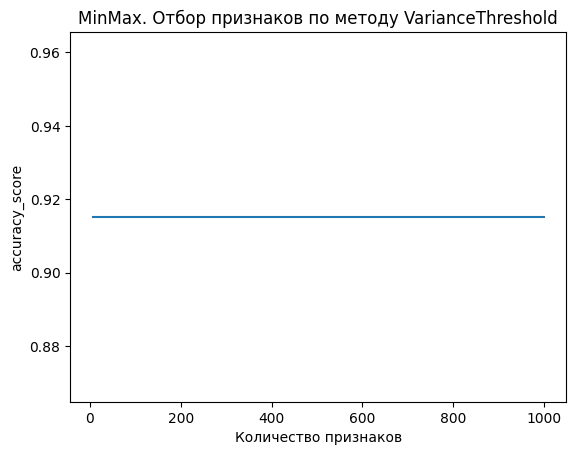

In [ ]:
plt.plot(x, accuracy_score_)
plt.xlabel("Количество признаков")
plt.ylabel("accuracy_score")
plt.title("MinMax. Отбор признаков по методу VarianceThreshold")
plt.savefig("variance_threshold_corr.png")

In [ ]:
find_maximal = np.argmax(accuracy_score_)
print("Максимальное значение accuracy получается на использовании", find_maximal, "признаках, accuracy равно ", accuracy_score_[find_maximal])

Максимальное значение accuracy получается на использовании 76 признаках, accuracy равно  0.9212121212121213


# Эксперименты. Различные модели многоклассовой классификации

In [ ]:
#Считывание матрицы признаков из файла
import numpy as np
def get_set(filename_dataset):
  dataset_nums = []
  data = []
  with open(filename_dataset, 'r') as f:
    strs = f.readlines()
    for line in strs:
      if len(line) > 2:
        new = line.split()
        new = list(map(lambda x: int(x), new))
        data += [new]
      else:
        new = int(line)
        data += [new]
  return data

In [ ]:
filename_x = '/content/sample_data/data_x_1000.txt'
filename_y = '/content/sample_data/data_y_1000.txt'
data_x = get_set(filename_x)
data_y = get_set(filename_y)

In [ ]:
with open('/content/sample_data/features.txt') as f:
  features = f.read()
  vector_of_features = features.split()
print('Признаки в модели:', vector_of_features)

Признаки в модели: ['1per', '2per', '3per', 'abbr', 'ablt', 'acc2', 'accs', 'actv', 'adjf', 'adjs', 'adjx', 'advb', 'af-p', 'anim', 'anph', 'anum', 'apro', 'arch', 'aspc', 'case', 'cmp2', 'coll', 'comp', 'conj', 'coun', 'datv', 'dist', 'dmns', 'erro', 'excl', 'femn', 'fimp', 'fixd', 'futr', 'gen1', 'gen2', 'gent', 'geox', 'gndr', 'grnd', 'hypo', 'impe', 'impf', 'impr', 'impx', 'inan', 'incl', 'indc', 'infn', 'infr', 'init', 'inmx', 'intj', 'intr', 'invl', 'litr', 'loc1', 'loc2', 'loct', 'masc', 'mood', 'ms-f', 'mult', 'name', 'neut', 'nmbr', 'nomn', 'noun', 'npro', 'numr', 'orgn', 'past', 'patr', 'perf', 'pers', 'pltm', 'plur', 'poss', 'post', 'prcl', 'prdx', 'pred', 'prep', 'pres', 'prnt', 'prtf', 'prts', 'pssv', 'qual', 'ques', 'refl', 'sgtm', 'sing', 'slng', 'subx', 'supr', 'surn', 'tens', 'trad', 'tran', 'trns', 'v-be', 'v-bi', 'v-ej', 'v-en', 'v-ey', 'v-ie', 'v-oy', 'v-sh', 'verb', 'voct', 'voic', 'vpre', 'ааа', 'ааб', 'аав', 'ааг', 'аад', 'аае', 'ааё', 'ааж', 'ааз', 'ааи', 'аай',

In [ ]:
#Получение данных в виде dataframe
import pandas as pd
columns, correlations = [], []

df = pd.DataFrame(data=data_x, columns=vector_of_features)
df['target'] = data_y
print(df[:10])

   1per  2per  3per  abbr  ablt  acc2  accs  actv  adjf  adjs  ...  romn  \
0     0     0     5     1     8     0    15     0    10     0  ...     2   
1     0     0     0     8     9     0     9     0    16     0  ...     0   
2     0     0     2     7     6     0    12     0    12     1  ...     0   
3     0     0     6     0    10     0    12     0     7     0  ...     0   
4    10     2    12     0     9     0    15     0    18     1  ...     0   
5     0     0     3     1     5     0     9     0    23     2  ...     1   
6     0     0     2     0    14     0     6     0    11     0  ...     1   
7     0     0     3     0     7     0    12     0    10     0  ...     3   
8     0     0    21     0    14     0    23     0    32     2  ...     0   
9     0     0     3     2     4     0     5     0    11     0  ...     0   

   unkn  qnt_freq_nouns  qnt_freq_verbs  qnt_freq_adjectives  \
0    13               4               4                    4   
1    11               1            

In [ ]:
#Обучаем линейную регрессию для проведения ранжирования признаков
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Нормализуем данные

scaler = StandardScaler()
data_x = scaler.fit_transform(data_x)

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.33, random_state=42)
reg = LinearRegression().fit(X_train, y_train)

In [ ]:
#Сортируем признаки по важности, исходя из коэффициента в формуле линейной регрессии

dict_features = dict(zip(vector_of_features, reg.coef_))
dict_features = dict(sorted(dict_features.items(), key=lambda x: abs(x[1]), reverse=True))
features_lin_reg = list(dict_features.keys())
print('Градация признаков. Критерий коэффициент в линейной регрессии: ', features_lin_reg)

Градация признаков. Критерий коэффициент в линейной регрессии:  ['пию', 'вье', 'latn', 'pnct', 'ишу', 'ыхи', 'мна', 'аке', 'romn', 'ате', 'злы', 'ссы', 'чки', 'лыл', 'нка', 'v-be', 'сна', 'ень', 'айт', 'рта', 'еня', 'чта', 'нья', 'оил', 'щах', 'йт', 'огу', 'тру', 'апы', 'епи', 'ьса', 'нь', 'ька', 'рху', 'conj', 'вры', 'чуг', 'ипу', 'бам', 'ррр', 'яля', 'цен', 'еть', 'оит', 'мко', 'ипы', 'игр', 'час', 'тца', 'туп', 'нет', 'йка', 'шка', 'ищи', 'шку', 'бым', 'гр', 'лез', 'unkn', 'иня', 'вде', 'воя', 'лни', 'очу', 'лаз', 'еин', 'моу', 'пид', 'fixd', 'дит', 'пей', 'ыск', 'и', 'амо', 'зла', 'ье', 'бят', 'ого', 'йлы', 'чок', 'лят', 'нас', 'щин', 'яка', 'ст', 'иша', 'дья', 'вию', 'зле', 'кто', 'нам', 'ыла', 'чко', 'озы', 'зды', 'ают', 'femn', 'ато', 'ови', 'мяч', 'ячу', 'ебе', 'шой', 'дла', 'лид', 'оец', 'юмо', 'ядю', 'яку', 'дю', 'йту', 'лца', 'обо', 'чу', 'тти', 'кмо', 'риа', 'ошо', 'шо', 'ваю', 'зли', 'ешь', 'удя', 'лго', 'нию', 'име', 'мье', 'ибы', 'бом', 'яча', 'збе', 'яно', 'яба', 'абу',

In [ ]:
#Подсчет корреляции
def correlation_ratio(numerical, categorical):

  values = np.array(numerical)
  ss_total = np.sum((values.mean() - values) ** 2)

  cats = np.unique(categorical, return_inverse = True)[1]

  ss_betweengroups = 0

  for c in np.unique(cats):

    group = values[np.argwhere(cats == c).flatten()]
    ss_betweengroups += len(group) * (group.mean() - values.mean()) ** 2

  return np.sqrt(ss_betweengroups/ss_total)

In [ ]:
#Получение датафрейма с данными
import pandas as pd
columns, correlations = [], []

df = pd.DataFrame(data=data_x, columns=vector_of_features)
df['target'] = data_y
print(df[:10, :10])

InvalidIndexError: (slice(None, 10, None), slice(None, 10, None))

In [ ]:
#1-Эксперимент(Нормализация: Standart_Scaler, вид отбора признаков: значимость коэффициентов в формуле линейной регрессии, подход: ovr)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#Нормализуем данные

X = df[features_line[:2]]
y = df['target']

scaler = StandardScaler()
data_x = scaler.fit_transform(X)
data_y = y

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.33, random_state=42)

ovr_model = LogisticRegression(multi_class = 'ovr')
ovr_model = ovr_model.fit(X_train, y_train)
y_pred = ovr_model.predict(X_test)
exp_1_accuracy = accuracy_score(y_test, y_pred)
print('Качество на эксперименте со StandartScaler, ovr и признаковым отбором по формуле линейной регрессии:', exp_1_accuracy)


Качество на эксперименте со StandartScaler, ovr и отбором признаков по формуле линейной регрессии: 0.9121212121212121


In [ ]:
#2-Эксперимент(Нормализация: Min_Max_Scaler, отбор признаков: значимость коэффициентов в формуле линейной регрессии, подход: ovr)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

#Нормализуем данные

X = df[features_line[:2]]
y = df['target']

scaler = MinMaxScaler()
data_x = scaler.fit_transform(X)
data_y = y

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.33, random_state=42)

ovr_model = LogisticRegression(multi_class = 'ovr')
ovr_model = ovr_model.fit(X_train, y_train)
y_pred = ovr_model.predict(X_test)
exp_2_accuracy = accuracy_score(y_test, y_pred)
print('Качество на эксперименте с MinMaxScaler, ovr и отбором признаков по формуле линейной регрессии', exp_2_accuracy)

Качество на эксперименте с MinMaxScaler, ovr и отбором признаков по формуле линейной регрессии 0.9151515151515152


In [ ]:
#4-Эксперимент(Нормализация: MinMax_Scaler, отбор признаков: значимость коэффициентов в линейной регрессии, подход: CategoricalNaiveBayass)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB

#Нормализуем данные

X = df[features_line[:2]]
y = df['target']

scaler = StandardScaler()
data_x = scaler.fit_transform(X)
data_y = y

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.33, random_state=42)

clf = NearestCentroid()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
exp_4_accuracy = accuracy_score(y_test, y_pred)
print('Качество на эксперименте с MinMaxScaler, ovr и отбором признаков по формуле линейной регрессии', exp_4_accuracy)

Качество на эксперименте с MinMaxScaler, ovr и отбором признаков по формуле линейной регрессии 0.03636363636363636


In [ ]:
#3-Эксперимент(Нормализация: Min_Max_Scaler, отбор признаков: значимость коэффициентов в линейной регрессии, подход: ovr)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB

#Нормализуем данные

X = df[features_correlation[:2]]
y = df['target']

scaler = MinMaxScaler()
data_x = scaler.fit_transform(X)
data_y = y

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.33, random_state=42)

clf = GaussianNB()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
exp_3_accuracy = accuracy_score(y_test, y_pred)
print('Качество на эксперименте с MinMaxScaler, GaussianNB и отбором признаков по формуле линейной регрессии:', exp_3_accuracy)

Качество на эксперименте с MinMaxScaler, GaussianNB и отбором признаков по формуле линейной регрессии: 0.9


In [ ]:
#5-Эксперимент(Нормализация: Standart_Scaler, отбор признаков: коэффициент корреляции, подход: ovr)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

#Нормализуем данные

X = df[features_correlation[:2]]
y = df['target']

scaler = StandardScaler()
data_x = scaler.fit_transform(X)
data_y = y

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.33, random_state=42)

ovr_model = LogisticRegression(multi_class = 'ovr')
ovr_model = ovr_model.fit(X_train, y_train)
y_pred = ovr_model.predict(X_test)
exp_5_accuracy = accuracy_score(y_test, y_pred)
print('Качество на эксперименте со StandartScaler, ovr и отбором признаков по корреляции:', exp_5_accuracy)


Качество на эксперименте со StandartScaler, ovr и отбором признаков по корреляции: 0.9181818181818182


In [ ]:
#6-Эксперимент(Нормализация: MinMaxScaler, отбор признаков: коэффициент корреляции, подход: ovr)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

#Нормализуем данные

X = df[features_correlation[:2]]
y = df['target']

scaler = MinMaxScaler()
data_x = scaler.fit_transform(X)
data_y = y

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.33, random_state=42)

ovr_model = LogisticRegression(multi_class = 'ovr')
ovr_model = ovr_model.fit(X_train, y_train)
y_pred = ovr_model.predict(X_test)
exp_6_accuracy = accuracy_score(y_test, y_pred)
print('Качество на эксперименте с MinMaxScaler, ovr и отбором признаков по корреляции:', exp_6_accuracy)

Качество на эксперименте с MinMaxScaler, ovr и отбором признаков по корреляции: 0.9151515151515152


In [ ]:
#7-Эксперимент(Нормализация: MinMaxScaler, отбор признаков: значимость коэффициентов в линейной регрессии, подход: NearestCentroid)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestCentroid

#Нормализуем данные

X = df[features_correlation[:2]]
y = df['target']

scaler = MinMaxScaler()
data_x = scaler.fit_transform(X)
data_y = y

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.33, random_state=42)

clf = NearestCentroid()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
exp_7_accuracy = accuracy_score(y_test, y_pred)
print('Качество на эксперименте с MinMaxScaler, NearestCentroid и отбором признаков по корреляции', exp_7_accuracy)

Качество на эксперименте с MinMaxScaler, NearestCentroid и отбором признаков по корреляции 0.7515151515151515


In [ ]:
#8-Эксперимент(Нормализация: StandartScaler, отбор признаков: значимость коэффициентов в линейной регрессии, подход: NearestCentroid)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import CategoricalNB
from sklearn.neighbors import NearestCentroid

#Нормализуем данные

X = df[features_correlation[:2]]
y = df['target']

scaler = MinMaxScaler()
data_x = scaler.fit_transform(X)
data_y = y

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.33, random_state=42)

clf = NearestCentroid()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
exp_8_accuracy = accuracy_score(y_test, y_pred)
print('Качество на эксперименте с StandartScaler, NearestCentroid и отбором признаков по корреляции', exp_8_accuracy)

Качество на эксперименте с StandartScaler, NearestCentroid и отбором признаков по корреляции 0.7515151515151515
